200HZ PPG -> 25hz 다운샘플링

In [ ]:
import os
import math
import numpy as np
import pandas as pd

def _try_scipy_lowpass(x: np.ndarray, fs: float, cutoff_hz: float = 10.0, order: int = 4) -> np.ndarray:
    """SciPy가 있으면 anti-alias 저역통과필터 적용, 없으면 그대로 반환."""
    try:
        from scipy.signal import butter, filtfilt
        nyq = 0.5 * fs
        wn = min(cutoff_hz / nyq, 0.99)
        b, a = butter(order, wn, btype="low")
        return filtfilt(b, a, x)
    except Exception:
        return x

def _infer_time_col(df: pd.DataFrame, time_col: str | None) -> str | None:
    if time_col and time_col in df.columns:
        return time_col
    candidates = ["time", "Time", "timestamp", "Timestamp", "t", "T", "sec", "ms"]
    for c in candidates:
        if c in df.columns:
            return c
    return None

def _estimate_fs_from_time(t_sec: np.ndarray) -> float | None:
    dt = np.diff(t_sec.astype(float))
    dt = dt[np.isfinite(dt)]
    if dt.size == 0:
        return None
    med = np.median(dt)
    if med <= 0:
        return None
    return 1.0 / med

def downsample_ppg_csv_200_to_25(
    input_path: str,
    output_path: str,
    target_fs: float = 25.0,
    input_fs_hint: float = 200.0,
    time_col: str | None = None,      # 예: "timestamp" (없으면 자동 탐색)
    method_no_time: str = "stride",   # 시간열 없을 때: "stride"(8개마다1개) or "mean"(블록평균)
    lowpass_cutoff_hz: float = 10.0,
    encoding: str | None = None       # 필요 시 'utf-8-sig', 'cp949' 등
):
    # CSV 읽기
    df = pd.read_csv(input_path, encoding=encoding) if encoding else pd.read_csv(input_path)

    tc = _infer_time_col(df, time_col)
    value_cols = [c for c in df.columns if c != tc]

    # 숫자형 컬럼만(PPG)
    numeric_cols = [c for c in value_cols if pd.api.types.is_numeric_dtype(df[c])]
    if len(numeric_cols) == 0:
        # 숫자인데 문자열로 들어온 경우가 많아서 강제 변환 시도
        numeric_cols = []
        for c in value_cols:
            coerced = pd.to_numeric(df[c], errors="coerce")
            if coerced.notna().sum() > 0:
                df[c] = coerced
                numeric_cols.append(c)
        if len(numeric_cols) == 0:
            raise ValueError("숫자형 PPG 컬럼을 찾지 못했습니다. CSV 컬럼 구성을 확인해 주세요.")

    meta = {"input_path": input_path, "target_fs": target_fs}

    if tc is not None:
        # 시간열 기반 리샘플링
        # datetime 문자열이면 파싱 시도
        if not np.issubdtype(df[tc].dtype, np.number):
            t_parsed = pd.to_datetime(df[tc], errors="coerce")
            if t_parsed.notna().all():
                t_sec = (t_parsed - t_parsed.iloc[0]).dt.total_seconds().to_numpy(dtype=float)
                meta["time_dtype"] = "datetime_parsed"
            else:
                # 숫자 변환 시도
                t_num = pd.to_numeric(df[tc], errors="coerce").to_numpy(dtype=float)
                if np.any(~np.isfinite(t_num)):
                    raise ValueError("time_col이 datetime/숫자로 해석되지 않습니다. time_col 지정/데이터를 확인해 주세요.")
                # ms 추정 변환
                if len(t_num) >= 3:
                    dt_med = float(np.median(np.diff(t_num)))
                    if np.isfinite(dt_med) and dt_med > 1.0:
                        t_num = t_num / 1000.0
                        meta["time_unit_guess"] = "ms->sec"
                t_sec = t_num - t_num[0]
                meta["time_dtype"] = "numeric_from_str"
        else:
            t_num = df[tc].to_numpy(dtype=float)
            if len(t_num) >= 3:
                dt_med = float(np.median(np.diff(t_num)))
                if np.isfinite(dt_med) and dt_med > 1.0:
                    t_num = t_num / 1000.0
                    meta["time_unit_guess"] = "ms->sec"
            t_sec = t_num - t_num[0]
            meta["time_dtype"] = "numeric"

        fs_est = _estimate_fs_from_time(t_sec)
        meta["input_fs_estimated"] = fs_est

        t_end = float(t_sec[-1])
        n_out = int(math.floor(t_end * target_fs)) + 1
        t_out = np.arange(n_out, dtype=float) / target_fs

        out = {tc: t_out}

        for c in numeric_cols:
            x = df[c].to_numpy(dtype=float)
            x = _try_scipy_lowpass(x, fs=(fs_est if fs_est else input_fs_hint), cutoff_hz=lowpass_cutoff_hz)

            if np.any(~np.isfinite(x)):
                x = pd.Series(x).interpolate(limit_direction="both").to_numpy(dtype=float)

            out[c] = np.interp(t_out, t_sec.astype(float), x.astype(float))

        out_df = pd.DataFrame(out)
        meta["mode"] = "time_based_resample"

    else:
        # 시간열 없으면 200→25 (factor=8) 인덱스 기반 다운샘플링
        factor = int(round(input_fs_hint / target_fs))
        if factor <= 0:
            raise ValueError("factor가 0 이하입니다. fs 설정을 확인해 주세요.")
        meta["mode"] = "index_based_downsample"
        meta["input_fs_used"] = input_fs_hint
        meta["factor"] = factor
        meta["method_no_time"] = method_no_time

        out = {}
        out["sample_index_25hz"] = np.arange(0, len(df), factor)

        for c in numeric_cols:
            x = df[c].to_numpy(dtype=float)
            x = _try_scipy_lowpass(x, fs=input_fs_hint, cutoff_hz=lowpass_cutoff_hz)

            if method_no_time == "mean":
                n = (len(x) // factor) * factor
                out[c] = x[:n].reshape(-1, factor).mean(axis=1)
            else:
                out[c] = x[::factor]

        out_df = pd.DataFrame({k: pd.Series(v) for k, v in out.items()})

    # CSV 저장
    os.makedirs(os.path.dirname(output_path) or ".", exist_ok=True)
    out_df.to_csv(output_path, index=False)

    return out_df, pd.DataFrame([meta])


# =========================
# 노트북에서 이렇게 실행하세요
# =========================
input_csv  = "/content/drive/MyDrive/Colab Notebooks/RealPPG/ppgRaw.csv"
output_csv = "/content/drive/MyDrive/Colab Notebooks/RealPPG/ppg_25hz.csv"

out_df, meta_df = downsample_ppg_csv_200_to_25(
    input_path=input_csv,
    output_path=output_csv,
    target_fs=25.0,
    input_fs_hint=200.0,
    time_col=None,           # 예: "timestamp"로 지정 가능
    method_no_time="stride", # 또는 "mean"
    lowpass_cutoff_hz=10.0,
    encoding=None            # 필요하면 'utf-8-sig' 또는 'cp949'
)

display(meta_df)
display(out_df.head())
print("Saved:", output_csv)


,input_path,target_fs,mode,input_fs_used,factor,method_no_time
0,/content/drive/MyDrive/Colab Notebooks/RealPPG...,25.0,index_based_downsample,200.0,8,stride


,sample_index_25hz,914925,6826.0
0,0,9.194621e+05,2244.471791
1,8,9.527405e+05,2296.289652
2,16,9.962772e+05,2246.477138
3,24,1.037935e+06,2107.194297
4,32,1.072394e+06,4126.838398


Saved: /content/drive/MyDrive/Colab Notebooks/RealPPG/ppg_25hz.csv


PPG HR Alignment & Window Filtering
(ABS anchor + timestamp(us/ms/s)/sample_index -> datetime restoration)
(Per-hour two windows: [24-30], [54-60])

Loaded files (raw):
  A: (153000, 10) @ 25.0Hz
  B: (758286, 3) @ 25.0Hz
  C: (6066288, 2) @ 200.0Hz

Applying absolute-time cutting...
ABS window: 2025-09-11 22:47:00 ~ 2025-09-12 07:08:00
✓ A: ABS-CUT 2025-09-11 22:47:00 ~ 2025-09-12 07:08:00  |  153000 rows → 153000 rows
[build_datetime_series] col=sample_index_25hz, kind=relative, unit=index, note=forced index by colname=sample_index_25hz
✓ B: ABS-CUT 2025-09-11 22:47:00 ~ 2025-09-12 07:08:00  |  758286 rows → 751501 rows
[build_datetime_series] col=sample_or_time, kind=epoch, unit=s, note=epoch s-ish (tmax=3.0e+10)
⚠ C: 절대시간 복원 실패/NaT 포함 → 절대시간 절단 생략

Loaded files (after abs-cut if applied):
  A: (153000, 10) @ 25.0Hz
  B: (751501, 3) @ 25.0Hz
  C: (6066288, 2) @ 200.0Hz

[A-25Hz] HR Estimation Debug
Signal length: 153000 samples (6120.0 sec)
NaN values: 0 (0.00%)
Lowpass filter: Appl

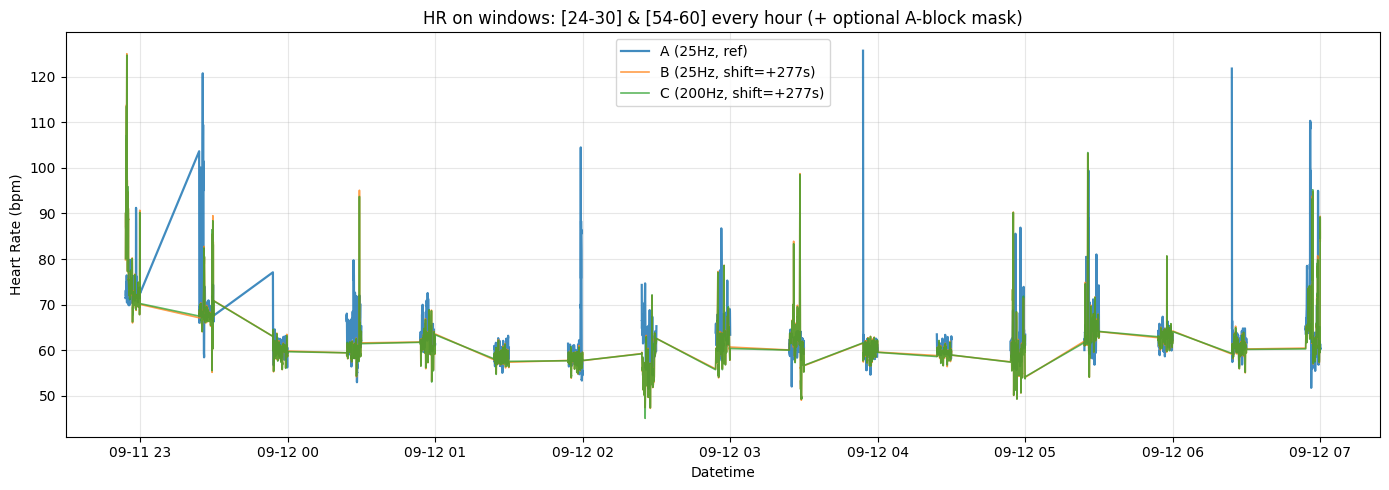


✓ Results saved to /content/drive/MyDrive/Colab Notebooks/RealPPG/


In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



# =========================
# 0) 사용자 설정
# =========================
file_a_25 = "/content/drive/MyDrive/Colab Notebooks/RealPPG/E0001.csv"
file_b_25 = "/content/drive/MyDrive/Colab Notebooks/RealPPG/ppg_25hz.csv"
file_c_200 = "/content/drive/MyDrive/Colab Notebooks/RealPPG/ppgRaw.csv"

FS_A = 25.0
FS_B = 25.0
FS_C = 200.0

MIN_BPM = 40
MAX_BPM = 200

# 매시간 2번 윈도우: 24~30분, 54~정각(60분)
WINDOW_PAIRS = ((24, 30), (54, 60))

# HR 추정 파라미터
PROM_SCALE = 0.2
SMOOTH_WIN = 5
MAX_INTERP_GAP_SEC = 8.0

# 전처리 파라미터 (공통 적용)
APPLY_LOWPASS = True
LOWPASS_CUTOFF_HZ = 10.0

# 정렬 파라미터
ALIGN_DURATION_SEC = 2 * 3600
MAX_SHIFT_SEC = 30 * 60

DEBUG_MODE = True

# 절대시간 기반 절단(세션 시작/종료)
CUT_BY_ABS_TIME = True
ABS_START_DT = "2025-09-11 22:47:00"
ABS_END_DT   = "2025-09-12 07:08:00"

# 6분 블록(간헐 기록) 감안
USE_A_BLOCK_MASK = True


# ============================================================
# 1) CSV 로딩/컬럼 추정
# ============================================================
def read_csv_robust(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)

    def is_numberish(x):
        try:
            float(str(x).strip())
            return True
        except Exception:
            return False

    # 헤더가 숫자처럼 보이면 header=None으로 재로딩
    if df.shape[1] >= 2 and all(is_numberish(c) for c in df.columns):
        df = pd.read_csv(path, header=None)

    # 2컬럼이면 (time_like, ppg)로 가정
    if df.shape[1] == 2:
        df.columns = ["sample_or_time", "ppg"]

    return df


def infer_ppg_col(df: pd.DataFrame) -> str:
    if "ppg" in df.columns:
        return "ppg"

    # numeric 변환 시도
    for c in df.columns:
        try:
            df[c] = pd.to_numeric(df[c])
        except Exception:
            pass

    num_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]

    exclude = set([
        "sample_index_25hz", "sample_index_200hz", "sample_index", "index", "Index",
        "timestamp", "sample_or_time", "time", "Time", "today", "date", "Date"
    ])
    num_cols = [c for c in num_cols if c not in exclude]

    if len(num_cols) == 0:
        raise ValueError("PPG 컬럼을 찾지 못했습니다. 컬럼명을 확인해 주세요.")
    return num_cols[-1]


def pick_time_col(df: pd.DataFrame):
    """
    시간컬럼 후보 우선순위:
      1) timestamp
      2) sample_or_time
      3) 이름에 time/stamp/tick 포함된 컬럼
      4) (fallback) 단조증가하는 숫자 컬럼
    """
    cols = list(df.columns)

    if "timestamp" in cols:
        return "timestamp"
    if "sample_or_time" in cols:
        return "sample_or_time"

    # 이름 기반
    for c in cols:
        cl = str(c).lower()
        if ("time" in cl) or ("stamp" in cl) or ("tick" in cl):
            return c

    # numeric 변환
    for c in cols:
        try:
            df[c] = pd.to_numeric(df[c])
        except Exception:
            pass

    num_cols = [c for c in cols if pd.api.types.is_numeric_dtype(df[c])]

    best = None
    best_score = -1e18
    for c in num_cols:
        x = df[c].to_numpy(dtype=float)
        x = x[np.isfinite(x)]
        if len(x) < 50:
            continue
        d = np.diff(x)
        inc_ratio = np.mean(d >= 0)
        # 완전 단조증가에 가까운 컬럼 선호
        score = inc_ratio
        if score > best_score:
            best_score = score
            best = c

    if best is not None and best_score > 0.95:
        return best
    return None


# ============================================================
# 2) timestamp 단위/형태 추정 (epoch vs relative, us/ms/s/index)
#   + sample_index류는 강제로 index 처리
# ============================================================
def infer_time_scale_from_timestamp(ts: np.ndarray, colname: str = "", fs_hint: float = None):
    ts = np.asarray(ts, dtype=float)
    ts = ts[np.isfinite(ts)]
    if len(ts) < 3:
        return ("relative", "index", None, "too_few_ts -> index")

    col_l = str(colname).lower()
    if ("sample_index" in col_l) or (col_l in ["index", "idx"]) or col_l.endswith("_index"):
        return ("relative", "index", None, f"forced index by colname={colname}")

    d = np.diff(ts)
    d = d[np.isfinite(d)]
    if len(d) < 2:
        return ("relative", "index", None, "too_few_diff -> index")

    dmed = float(np.median(d))
    tmax = float(np.max(ts))
    tmin = float(np.min(ts))

    # epoch-like magnitude
    if tmax > 1e14:
        if dmed > 1e8:
            return ("epoch", "ns", None, f"epoch ns (dmed={dmed:.1f})")
        elif dmed > 1e5:
            return ("epoch", "us", None, f"epoch us (dmed={dmed:.1f})")
        elif dmed > 1e2:
            return ("epoch", "ms", None, f"epoch ms (dmed={dmed:.1f})")
        else:
            return ("epoch", "s", None, f"epoch s (dmed={dmed:.1f})")

    if 1e11 < tmax <= 1e14:
        return ("epoch", "ms", None, f"epoch ms-ish (tmax={tmax:.1e})")

    if 1e8 < tmax <= 1e11:
        return ("epoch", "s", None, f"epoch s-ish (tmax={tmax:.1e})")

    # relative: 200Hz라면 us:~5000, ms:~5, s:~0.005, index:~1
    if 0.5 <= dmed <= 2.0:
        return ("relative", "index", None, f"relative index-like (dmed={dmed:.3f})")

    cand = []
    if dmed > 0:
        cand.append(("us", 1e6 / dmed))
        cand.append(("ms", 1e3 / dmed))
        cand.append(("s", 1.0 / dmed))

    def score(fs):
        if fs <= 0:
            return -1e9
        base = -abs(fs - 200.0)
        # fs_hint가 있으면 그쪽도 약간 반영
        if fs_hint is not None:
            base += -0.2 * abs(fs - fs_hint)
        return base

    best = None
    best_score = -1e18
    for unit, fs_est in cand:
        if 5 <= fs_est <= 5000:
            sc = score(fs_est)
            if sc > best_score:
                best_score = sc
                best = (unit, fs_est)

    if best is None:
        if dmed > 1000:
            return ("relative", "us", 1e6, f"relative us fallback (dmed={dmed:.1f})")
        elif dmed > 1:
            return ("relative", "ms", 1e3, f"relative ms fallback (dmed={dmed:.3f})")
        else:
            return ("relative", "s", 1.0, f"relative s fallback (dmed={dmed:.6f})")

    unit, fs_est = best
    to_div = {"us": 1e6, "ms": 1e3, "s": 1.0}[unit]
    return ("relative", unit, to_div, f"relative {unit} (fs_est≈{fs_est:.1f}Hz, dmed={dmed:.3f}, range=[{tmin:.1f},{tmax:.1f}])")


# ============================================================
# 3) 절대시간(datetime) & 절대초(t_abs_sec) 만들기
#   - relative timestamp는 ts 자체를 경과시간으로 사용(중요)
# ============================================================
def build_datetime_series(df: pd.DataFrame, fs: float, anchor_dt: pd.Timestamp) -> pd.Series:
    # A: today/time
    if ("today" in df.columns) and ("time" in df.columns):
        dt = pd.to_datetime(df["today"].astype(str) + " " + df["time"].astype(str), errors="coerce")
        return pd.Series(dt)

    tc = pick_time_col(df)
    if tc is None:
        return pd.Series([pd.NaT] * len(df))

    ts = pd.to_numeric(df[tc], errors="coerce").to_numpy(dtype=float)
    if np.isfinite(ts).sum() < 3:
        return pd.Series([pd.NaT] * len(df))

    kind, unit, to_div, note = infer_time_scale_from_timestamp(ts, colname=tc, fs_hint=fs)
    if DEBUG_MODE:
        print(f"[build_datetime_series] col={tc}, kind={kind}, unit={unit}, note={note}")

    if kind == "epoch":
        return pd.Series(pd.to_datetime(ts, unit=unit, errors="coerce"))

    # relative
    if unit == "index":
        elapsed = np.arange(len(df), dtype=float) / fs
        dt = anchor_dt + pd.to_timedelta(elapsed, unit="s")
        return pd.Series(dt)
    else:
        # ★ ts 자체를 경과시간으로 사용
        elapsed = ts / to_div
        dt = anchor_dt + pd.to_timedelta(elapsed, unit="s")
        return pd.Series(dt)


def build_time_abs_seconds(df: pd.DataFrame, fs: float, anchor_dt: pd.Timestamp) -> np.ndarray:
    dt = build_datetime_series(df, fs, anchor_dt)
    if dt.notna().all():
        delta = (dt - anchor_dt)  # Series of Timedelta
        # Series/TimedeltaIndex 모두 안전하게 초로
        sec = delta.to_numpy() / np.timedelta64(1, "s")
        return sec.astype(float)

    return (np.arange(len(df), dtype=float) / fs).astype(float)


def cut_by_abs_time(df: pd.DataFrame, fs: float, start_dt: pd.Timestamp, end_dt: pd.Timestamp,
                    label: str, anchor_dt: pd.Timestamp):
    dt = build_datetime_series(df, fs, anchor_dt)
    if dt.isna().any():
        print(f"⚠ {label}: 절대시간 복원 실패/NaT 포함 → 절대시간 절단 생략")
        return df

    m = (dt >= start_dt) & (dt <= end_dt)
    out = df.loc[m].reset_index(drop=True)
    print(f"✓ {label}: ABS-CUT {start_dt} ~ {end_dt}  |  {len(df)} rows → {len(out)} rows")
    return out


# ============================================================
# 4) 전처리
# ============================================================
def apply_lowpass_filter(x: np.ndarray, fs: float, cutoff_hz: float = 10.0, order: int = 4) -> np.ndarray:
    try:
        from scipy.signal import butter, filtfilt
        nyq = 0.5 * fs
        wn = min(cutoff_hz / nyq, 0.99)
        b, a = butter(order, wn, btype="low")
        return filtfilt(b, a, x)
    except Exception:
        print("⚠ WARNING: scipy not available, skipping lowpass filter")
        return x


def bandpass_ppg(x: np.ndarray, fs: float, f_lo: float, f_hi: float, order: int = 4) -> np.ndarray:
    try:
        from scipy.signal import butter, filtfilt, detrend
        x0 = detrend(x)
        nyq = 0.5 * fs
        lo = max(f_lo / nyq, 1e-6)
        hi = min(f_hi / nyq, 0.999)
        b, a = butter(order, [lo, hi], btype="band")
        return filtfilt(b, a, x0)
    except Exception:
        w = int(max(1, round(fs * 0.8)))
        baseline = pd.Series(x).rolling(w, center=True, min_periods=1).mean().to_numpy()
        return x - baseline


def preprocess_ppg(x: np.ndarray, fs: float,
                   apply_lowpass: bool = True,
                   lowpass_cutoff_hz: float = 10.0) -> np.ndarray:
    if np.any(~np.isfinite(x)):
        x = pd.Series(x).interpolate(limit_direction="both").to_numpy(dtype=float)

    if apply_lowpass:
        x = apply_lowpass_filter(x, fs, cutoff_hz=lowpass_cutoff_hz, order=4)

    return bandpass_ppg(x, fs, f_lo=MIN_BPM/60.0, f_hi=MAX_BPM/60.0, order=4)


# ============================================================
# 5) HR(1Hz) 추정 (t_abs_sec 사용)
# ============================================================
def estimate_hr_1hz_gapmasked(df: pd.DataFrame, fs: float, anchor_dt: pd.Timestamp,
                              max_interp_gap_sec: float,
                              file_label: str = "",
                              apply_lowpass: bool = True,
                              lowpass_cutoff_hz: float = 10.0) -> pd.DataFrame:
    ppg_col = infer_ppg_col(df)
    t_abs = build_time_abs_seconds(df, fs, anchor_dt)

    x = pd.to_numeric(df[ppg_col], errors="coerce").to_numpy(dtype=float)
    nan_count = np.sum(~np.isfinite(x))

    x_f = preprocess_ppg(x, fs, apply_lowpass=apply_lowpass, lowpass_cutoff_hz=lowpass_cutoff_hz)

    min_dist = int(round((60.0 / MAX_BPM) * fs))
    base_prominence = PROM_SCALE * np.std(x_f)

    if DEBUG_MODE:
        print(f"\n{'='*60}")
        print(f"[{file_label}] HR Estimation Debug")
        print(f"{'='*60}")
        print(f"Signal length: {len(x_f)} samples ({len(x_f)/fs:.1f} sec)")
        print(f"NaN values: {nan_count} ({100*nan_count/len(x):.2f}%)")
        print(f"Lowpass filter: {'Applied' if apply_lowpass else 'Skipped'} ({lowpass_cutoff_hz}Hz)")
        print(f"Signal std: {np.std(x_f):.3f}")
        print(f"Base prominence: {base_prominence:.3f}")
        print(f"Min distance: {min_dist} samples ({min_dist/fs:.2f} sec)")

    try:
        from scipy.signal import find_peaks
        peaks, _ = find_peaks(x_f, distance=max(1, min_dist), prominence=base_prominence)
    except Exception as e:
        print(f"Peak detection failed: {e}")
        peaks = []
        for i in range(1, len(x_f) - 1):
            if x_f[i-1] < x_f[i] and x_f[i] > x_f[i+1]:
                peaks.append(i)
        peaks = np.array(peaks, dtype=int)

    if len(peaks) < 2:
        print(f"ERROR: Too few peaks ({len(peaks)})!")
        return pd.DataFrame({"t_sec": [], "hr_bpm": []})

    tp = t_abs[peaks]
    ibi = np.diff(tp)

    hr = 60.0 / ibi
    th = tp[1:]

    valid = np.isfinite(hr) & (hr >= MIN_BPM) & (hr <= MAX_BPM)
    hr = hr[valid]
    th = th[valid]

    if len(hr) < 2:
        return pd.DataFrame({"t_sec": [], "hr_bpm": []})

    # 1Hz grid (anchor 기준 절대초)
    t1 = np.arange(np.ceil(th.min()), np.floor(th.max()) + 1e-9, 1.0)
    hr1 = np.full_like(t1, np.nan, dtype=float)

    gaps = np.diff(th)
    cut = np.where(gaps > max_interp_gap_sec)[0]
    starts = np.r_[0, cut + 1]
    ends   = np.r_[cut, len(th) - 1]

    for s, e in zip(starts, ends):
        if e - s < 1:
            continue
        t_start, t_end = th[s], th[e]
        m = (t1 >= t_start) & (t1 <= t_end)
        if m.sum() == 0:
            continue
        hr1[m] = np.interp(t1[m], th[s:e+1], hr[s:e+1])

    if SMOOTH_WIN and SMOOTH_WIN > 1:
        hr1 = pd.Series(hr1).rolling(SMOOTH_WIN, center=True, min_periods=1).mean().to_numpy()

    return pd.DataFrame({"t_sec": t1, "hr_bpm": hr1})


# ============================================================
# 6) HR 기반 shift 최적화
# ============================================================
def best_shift_by_corr_nanaware(hr_ref: pd.DataFrame, hr_tar: pd.DataFrame,
                                align_duration_sec: int, max_shift_sec: int):
    if len(hr_ref) < 60 or len(hr_tar) < 60:
        return 0, np.nan

    T = int(align_duration_sec)
    grid = np.arange(0, T + 1, 1.0)

    ref = np.interp(grid, hr_ref["t_sec"], hr_ref["hr_bpm"], left=np.nan, right=np.nan)
    tar = np.interp(grid, hr_tar["t_sec"], hr_tar["hr_bpm"], left=np.nan, right=np.nan)

    m = np.isfinite(ref) & np.isfinite(tar)
    if m.sum() < 300:
        return 0, np.nan

    ref_valid = ref[m]
    tar_valid = tar[m]
    ref_mean, ref_std = np.mean(ref_valid), np.std(ref_valid)
    tar_mean, tar_std = np.mean(tar_valid), np.std(tar_valid)

    refZ = np.where(m, (ref - ref_mean) / (ref_std + 1e-9), np.nan)
    tarZ = np.where(m, (tar - tar_mean) / (tar_std + 1e-9), np.nan)

    best_s, best_r = 0, -1e9

    if DEBUG_MODE:
        print(f"\n[Alignment] Searching shift range: [{-max_shift_sec}, {max_shift_sec}]s")
        print(f"[Alignment] Valid overlap points: {m.sum()}/{len(grid)}")

    for s in range(-max_shift_sec, max_shift_sec + 1):
        if s >= 0:
            rr = refZ[s:]
            tt = tarZ[:len(rr)]
        else:
            rr = refZ[:len(refZ)+s]
            tt = tarZ[-s:]

        v = np.isfinite(rr) & np.isfinite(tt)
        if v.sum() < 300:
            continue

        r = float(np.corrcoef(rr[v], tt[v])[0, 1])
        if r > best_r:
            best_r, best_s = r, s

    return best_s, best_r


# ============================================================
# 7) 윈도우 생성/필터
# ============================================================
def make_two_windows_per_hour(dt_start: pd.Timestamp, dt_end: pd.Timestamp,
                              pairs=((24, 30), (54, 60))):
    floor_hour = dt_start.floor("h") - pd.Timedelta(hours=1)
    ceil_hour  = dt_end.ceil("h") + pd.Timedelta(hours=1)

    hours = pd.date_range(floor_hour, ceil_hour, freq="h")
    windows = []
    for h in hours:
        for (m0, m1) in pairs:
            w_start = h + pd.Timedelta(minutes=int(m0))
            w_end = (h + pd.Timedelta(hours=1)) if int(m1) >= 60 else (h + pd.Timedelta(minutes=int(m1)))
            if w_end <= dt_start or w_start >= dt_end:
                continue
            windows.append((max(w_start, dt_start), min(w_end, dt_end)))
    return sorted(windows, key=lambda x: x[0])


def filter_by_windows(hr_df: pd.DataFrame, anchor_dt: pd.Timestamp, windows):
    if len(hr_df) == 0:
        return hr_df
    out = hr_df.copy()
    out["dt"] = anchor_dt + pd.to_timedelta(out["t_sec"], unit="s")

    mask = pd.Series(False, index=out.index)
    for ws, we in windows:
        mask |= (out["dt"] >= ws) & (out["dt"] < we)
    return out.loc[mask].reset_index(drop=True)


def apply_a_block_mask(hr_df: pd.DataFrame, valid_sec: np.ndarray):
    if len(hr_df) == 0:
        return hr_df
    sec = np.round(hr_df["t_sec"].to_numpy(dtype=float)).astype(np.int64)
    valid_sec = np.asarray(valid_sec, dtype=np.int64)
    mask = np.isin(sec, valid_sec)
    return hr_df.loc[mask].reset_index(drop=True)


# ============================================================
# 8) 실행
# ============================================================
anchor_dt = pd.to_datetime(ABS_START_DT)
start_dt = pd.to_datetime(ABS_START_DT)
end_dt   = pd.to_datetime(ABS_END_DT)

print("="*60)
print("PPG HR Alignment & Window Filtering")
print("(ABS anchor + timestamp(us/ms/s)/sample_index -> datetime restoration)")
print("(Per-hour two windows: [24-30], [54-60])")
print("="*60)

dfa = read_csv_robust(file_a_25)
dfb = read_csv_robust(file_b_25)
dfc = read_csv_robust(file_c_200)

print(f"\nLoaded files (raw):")
print(f"  A: {dfa.shape} @ {FS_A}Hz")
print(f"  B: {dfb.shape} @ {FS_B}Hz")
print(f"  C: {dfc.shape} @ {FS_C}Hz")

if CUT_BY_ABS_TIME:
    print(f"\n{'='*60}")
    print("Applying absolute-time cutting...")
    print(f"ABS window: {start_dt} ~ {end_dt}")
    print(f"{'='*60}")

    dfa = cut_by_abs_time(dfa, FS_A, start_dt, end_dt, "A", anchor_dt)
    dfb = cut_by_abs_time(dfb, FS_B, start_dt, end_dt, "B", anchor_dt)
    dfc = cut_by_abs_time(dfc, FS_C, start_dt, end_dt, "C", anchor_dt)

print(f"\nLoaded files (after abs-cut if applied):")
print(f"  A: {dfa.shape} @ {FS_A}Hz")
print(f"  B: {dfb.shape} @ {FS_B}Hz")
print(f"  C: {dfc.shape} @ {FS_C}Hz")

# HR 추정 (t_sec는 anchor_dt 기준 절대초)
hr_a = estimate_hr_1hz_gapmasked(dfa, FS_A, anchor_dt, MAX_INTERP_GAP_SEC, "A-25Hz",
                                 apply_lowpass=APPLY_LOWPASS, lowpass_cutoff_hz=LOWPASS_CUTOFF_HZ)
hr_b = estimate_hr_1hz_gapmasked(dfb, FS_B, anchor_dt, MAX_INTERP_GAP_SEC, "B-25Hz",
                                 apply_lowpass=APPLY_LOWPASS, lowpass_cutoff_hz=LOWPASS_CUTOFF_HZ)
hr_c = estimate_hr_1hz_gapmasked(dfc, FS_C, anchor_dt, MAX_INTERP_GAP_SEC, "C-200Hz",
                                 apply_lowpass=APPLY_LOWPASS, lowpass_cutoff_hz=LOWPASS_CUTOFF_HZ)

if len(hr_a) == 0 or len(hr_b) == 0 or len(hr_c) == 0:
    raise RuntimeError("HR 추정 결과가 비었습니다. (A/B/C 중 하나)")

print(f"\n{'='*60}")
print("Computing time alignment...")
print(f"{'='*60}")

shift_b, corr_b = best_shift_by_corr_nanaware(hr_a, hr_b, ALIGN_DURATION_SEC, MAX_SHIFT_SEC)
shift_c, corr_c = best_shift_by_corr_nanaware(hr_a, hr_c, ALIGN_DURATION_SEC, MAX_SHIFT_SEC)

print(f"\n[Result] B alignment: shift={shift_b:+.0f}s, corr={corr_b:.3f}")
print(f"[Result] C alignment: shift={shift_c:+.0f}s, corr={corr_c:.3f}")

hr_b_aligned = hr_b.copy()
hr_b_aligned["t_sec"] = hr_b_aligned["t_sec"] + shift_b

hr_c_aligned = hr_c.copy()
hr_c_aligned["t_sec"] = hr_c_aligned["t_sec"] + shift_c

# 윈도우 생성: 실제 절대시간 범위로 제한
dt_a_start = anchor_dt + pd.to_timedelta(float(np.nanmin(hr_a["t_sec"])), unit="s")
dt_a_end   = anchor_dt + pd.to_timedelta(float(np.nanmax(hr_a["t_sec"])), unit="s")
dt_a_start = max(dt_a_start, start_dt)
dt_a_end   = min(dt_a_end, end_dt)

print(f"\n{'='*60}")
print("Generating time windows...")
print(f"{'='*60}")
print(f"Time range: {dt_a_start} to {dt_a_end}")

windows = make_two_windows_per_hour(dt_a_start, dt_a_end, pairs=WINDOW_PAIRS)
print(f"Generated {len(windows)} windows per-hour pairs={WINDOW_PAIRS}")
if windows:
    print(f"First window: {windows[0]}")
    print(f"Last window:  {windows[-1]}")

# 윈도우 필터 적용
fa = filter_by_windows(hr_a, anchor_dt, windows)
fb = filter_by_windows(hr_b_aligned, anchor_dt, windows)
fc = filter_by_windows(hr_c_aligned, anchor_dt, windows)

# A의 유효초만 B/C에도 적용
if USE_A_BLOCK_MASK:
    valid_sec = np.round(fa.loc[fa["hr_bpm"].notna(), "t_sec"].to_numpy(dtype=float)).astype(np.int64)
    valid_sec = np.unique(valid_sec)
    fb = apply_a_block_mask(fb, valid_sec)
    fc = apply_a_block_mask(fc, valid_sec)
    if DEBUG_MODE:
        print(f"\n[6-min block masking] A-valid seconds: {len(valid_sec)} points")
        print(f"[6-min block masking] After mask: B={len(fb)}, C={len(fc)}")

print(f"\n{'='*60}")
print("Final Results")
print(f"{'='*60}")
print(f"  A: {fa['hr_bpm'].notna().sum():5d} / {len(fa):5d} ({100*fa['hr_bpm'].notna().mean():.1f}%)")
print(f"  B: {fb['hr_bpm'].notna().sum():5d} / {len(fb):5d} ({100*fb['hr_bpm'].notna().mean():.1f}%)")
print(f"  C: {fc['hr_bpm'].notna().sum():5d} / {len(fc):5d} ({100*fc['hr_bpm'].notna().mean():.1f}%)")

# Plot
plt.figure(figsize=(14, 5))
plt.plot(fa["dt"], fa["hr_bpm"], label="A (25Hz, ref)", alpha=0.85, linewidth=1.6)
plt.plot(fb["dt"], fb["hr_bpm"], label=f"B (25Hz, shift={shift_b:+.0f}s)", alpha=0.75, linewidth=1.2)
plt.plot(fc["dt"], fc["hr_bpm"], label=f"C (200Hz, shift={shift_c:+.0f}s)", alpha=0.75, linewidth=1.2)
plt.xlabel("Datetime")
plt.ylabel("Heart Rate (bpm)")
plt.title("HR on windows: [24-30] & [54-60] every hour (+ optional A-block mask)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Save
output_dir = "/content/drive/MyDrive/Colab Notebooks/RealPPG/"
suffix = "win_24-30_54-60"
if USE_A_BLOCK_MASK:
    suffix += "_Ablock"

fa.to_csv(output_dir + f"HR_final_A_25_{suffix}.csv", index=False)
fb.to_csv(output_dir + f"HR_final_B_25_{suffix}_shift{shift_b:+.0f}s.csv", index=False)
fc.to_csv(output_dir + f"HR_final_C_200_{suffix}_shift{shift_c:+.0f}s.csv", index=False)

print(f"\n✓ Results saved to {output_dir}")


[Picked files]
 A_PATH: /content/drive/MyDrive/Colab Notebooks/RealPPG/HR_final_A_25_win_24-30_54-60_Ablock.csv
 B_PATH: /content/drive/MyDrive/Colab Notebooks/RealPPG/HR_raw_B_25_shifted_dt.csv
 C_PATH: /content/drive/MyDrive/Colab Notebooks/RealPPG/HR_raw_C_200_shifted_dt.csv
LOAD + DT RESTORE (anchor-based) + ABS CUT + WINDOWS
[A] dt restore: use existing dt, rows=6117
[B] dt restore: relative seconds by col=t_sec, rows=30329
[C] dt restore: relative seconds by col=t_sec, rows=30326
[ABS CUT] A=6117, B=30061, C=30061
[A-block masking] A valid dt: 6092
[A-block masking] B: 6120 -> 6107
[A-block masking] C: 6120 -> 6107

STEP 1) Re-align B <-> C WITHOUT using A
[BC best shift] shift=0s, corr=0.9172, MAE=1.179, n=6107
[B vs C] pairs=6107, r=0.9172, MAE=1.179, RMSE=2.469, Bias=0.006

STEP 2) Align A <-> C by window-wise shift (gated + drift fallback)

[Shift table]
               wstart  shift      corr       mae    n   good  shift_smooth  \
0 2025-09-11 22:54:00      0  0.641966  2.689

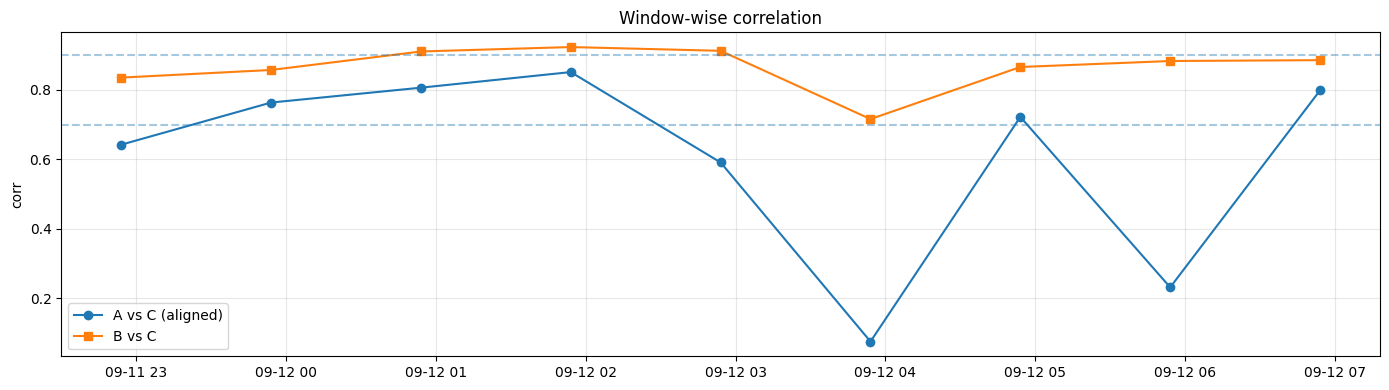

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

import glob
import os

OUT_DIR = "/content/drive/MyDrive/Colab Notebooks/RealPPG/"

def pick_one(patterns):
    for p in patterns:
        cand = sorted(glob.glob(os.path.join(OUT_DIR, p)))
        if cand:
            # 가장 마지막(이름 정렬상 최신으로 가정). 필요하면 os.path.getmtime로 바꿔도 됨.
            return cand[-1]
    return None

# 1) 최우선: HR_final_* (윈도우+마스크 적용된 최종)
A_PATH = pick_one([
    "HR_final_A_25_win_24-30_54-60_Ablock.csv",
    "HR_final_A_25_win_24-30_54-60*.csv",
    "HR_final_A_25_*.csv",
])

B_PATH = pick_one([
    "HR_final_B_25_win_24-30_54-60_Ablock_shift*sec.csv",
    "HR_final_B_25_win_24-30_54-60*_shift*sec.csv",
    "HR_final_B_25_*shift*sec.csv",
])

C_PATH = pick_one([
    "HR_final_C_200_win_24-30_54-60_Ablock_shift*sec.csv",
    "HR_final_C_200_win_24-30_54-60*_shift*sec.csv",
    "HR_final_C_200_*shift*sec.csv",
])

# 2) fallback: HR_raw_* (윈도우/마스크 전, dt는 shift 반영된 파일)
if A_PATH is None:
    A_PATH = pick_one(["HR_raw_A_25.csv"])
if B_PATH is None:
    B_PATH = pick_one(["HR_raw_B_25_shifted_dt.csv"])
if C_PATH is None:
    C_PATH = pick_one(["HR_raw_C_200_shifted_dt.csv"])

print("[Picked files]")
print(" A_PATH:", A_PATH)
print(" B_PATH:", B_PATH)
print(" C_PATH:", C_PATH)

assert A_PATH is not None, "A 참조파일을 OUT_DIR에서 찾지 못했습니다."
assert B_PATH is not None, "B 참조파일을 OUT_DIR에서 찾지 못했습니다."
assert C_PATH is not None, "C 참조파일을 OUT_DIR에서 찾지 못했습니다."

OUT_DIR = "/content/drive/MyDrive/Colab Notebooks/RealPPG/"

# -------------------------
# 세션 절대시간 (앵커)
# -------------------------
ABS_START_DT = "2025-09-11 22:47:00"
ABS_END_DT   = "2025-09-12 07:08:00"
ANCHOR_DT = pd.to_datetime(ABS_START_DT)
CUT_START = pd.to_datetime(ABS_START_DT)
CUT_END   = pd.to_datetime(ABS_END_DT)

# -------------------------
# 샘플링레이트 (B/C 시간복원에 사용)
# -------------------------
FS_B = 25.0
FS_C = 200.0

# -------------------------
# 윈도우 정의
# -------------------------
START_MINUTE = 54  # wstart 기준
WINDOW_PAIRS = ((24, 30), (54, 60))

# merge_asof tolerance
ASOF_TOL_BC_SEC = 1
ASOF_TOL_AC_SEC = 3   # A<->(B,C)는 1Hz라 2~3초 권장

# A-block masking
USE_A_BLOCK_MASK = True
A_BLOCK_TOL_SEC = 1

# B<->C global shift 탐색
BC_SHIFT_SEARCH_SEC = 1800
BC_SHIFT_STEP_SEC   = 5
BC_MIN_N = 300

# A<->C window-wise shift 탐색
SHIFT_SEARCH_SEC = 1800
SHIFT_STEP_SEC   = 5
MIN_N_IN_WINDOW  = 120

# 게이트(완화 가능)
CORR_GATE = 0.55
MAE_GATE  = 6.0

# drift fallback
USE_DRIFT_FALLBACK = True
DRIFT_ROBUST = True
DRIFT_MIN_GOOD = 2

ROUND_TO_STEP = True


# ============================================================
# Utils: dt 복원(핵심)
# ============================================================
def _to_numeric_series(df, col):
    if col not in df.columns:
        return None
    s = pd.to_numeric(df[col], errors="coerce")
    if s.notna().sum() < 3:
        return None
    return s

def infer_relative_unit_from_series(v):
    """
    v: numeric array
    return: ("us"/"ms"/"s"/"index", scale_div)
      - us: elapsed_sec = (v - v0)/1e6
      - ms: elapsed_sec = (v - v0)/1e3
      - s : elapsed_sec = (v - v0)
      - index: elapsed_sec = (i)/fs (외부에서 처리)
    """
    v = np.asarray(v, dtype=float)
    v = v[np.isfinite(v)]
    if len(v) < 3:
        return ("index", None, "too_few")

    d = np.diff(v)
    d = d[np.isfinite(d)]
    if len(d) < 2:
        return ("index", None, "too_few_diff")

    dmed = float(np.median(d))
    vmax = float(np.max(v))
    vmin = float(np.min(v))

    # epoch-like는 여기서 다루지 않음 (HR_selected 파일은 보통 상대/인덱스)
    # relative tick/unit 판정
    # - 200Hz라면 sample dt ~ 0.005s
    #   us: dmed ~ 5000
    #   ms: dmed ~ 5
    #   s : dmed ~ 0.005
    # - index: dmed ~ 1
    if 0.5 <= dmed <= 2.0:
        return ("index", None, f"index-like dmed={dmed:.3f}, range=[{vmin:.1f},{vmax:.1f}]")

    # us 후보
    fs_us = 1e6 / dmed if dmed > 0 else np.nan
    fs_ms = 1e3 / dmed if dmed > 0 else np.nan
    fs_s  = 1.0 / dmed if dmed > 0 else np.nan

    # 200Hz 근처 선호
    def score(fs):
        if not np.isfinite(fs) or fs <= 0:
            return -1e18
        if fs < 10 or fs > 2000:
            return -1e18
        return -abs(fs - 200.0)

    cand = [
        ("us", 1e6, fs_us),
        ("ms", 1e3, fs_ms),
        ("s",  1.0, fs_s),
    ]
    best = None
    best_sc = -1e18
    for u, div, fs_est in cand:
        sc = score(fs_est)
        if sc > best_sc:
            best_sc = sc
            best = (u, div, fs_est)

    if best is None or best_sc < -1e17:
        # fallback: 크기 기준
        if dmed > 1000:
            return ("us", 1e6, f"fallback us dmed={dmed:.1f}")
        elif dmed > 1:
            return ("ms", 1e3, f"fallback ms dmed={dmed:.3f}")
        else:
            return ("s", 1.0, f"fallback s dmed={dmed:.6f}")

    u, div, fs_est = best
    return (u, div, f"infer {u} (fs_est≈{fs_est:.1f}Hz, dmed={dmed:.3f}, range=[{vmin:.1f},{vmax:.1f}])")

def restore_dt(df, *,
               anchor_dt: pd.Timestamp,
               fs: float,
               prefer_dt_col=True,
               force_index_cols=()):
    """
    df에 dt가 있으면 사용하되,
    B/C는 sample_index / tick 기반 복원이 필요하면 여기서 처리.
    force_index_cols: (colname,) 이면 그 컬럼은 무조건 index로 취급(예: sample_index_25hz)
    """
    out = df.copy()

    # 1) 기존 dt가 있으면 우선 시도
    if prefer_dt_col and ("dt" in out.columns):
        dt0 = pd.to_datetime(out["dt"], errors="coerce")
        if dt0.notna().sum() >= 3:
            out["dt"] = dt0
            return out, "use existing dt"

    # 2) 후보 time-like 컬럼들
    candidates = [
        "sample_index_25hz", "sample_index_200hz", "sample_index",
        "t_sec", "t", "time_sec",
        "timestamp", "sample_or_time"
    ]

    chosen = None
    for col in candidates:
        s = _to_numeric_series(out, col)
        if s is None:
            continue
        chosen = col
        break

    if chosen is None:
        # 최후: 인덱스 기반
        out["dt"] = anchor_dt + pd.to_timedelta(np.arange(len(out)) / fs, unit="s")
        return out, "fallback index (no time-like col)"

    s = _to_numeric_series(out, chosen)
    v = s.to_numpy(dtype=float)

    # 강제 index 처리
    if chosen in set(force_index_cols) or "sample_index" in chosen:
        elapsed = v / fs
        out["dt"] = anchor_dt + pd.to_timedelta(elapsed, unit="s")
        return out, f"forced index by col={chosen}"

    # t_sec 계열이면 그대로 seconds
    if chosen in ("t_sec", "t", "time_sec"):
        elapsed = v - np.nanmin(v)
        out["dt"] = anchor_dt + pd.to_timedelta(elapsed, unit="s")
        return out, f"relative seconds by col={chosen}"

    # tick/timestamp 계열: Δmedian 기반 unit 판정
    unit, div, note = infer_relative_unit_from_series(v)
    if unit == "index":
        out["dt"] = anchor_dt + pd.to_timedelta(np.arange(len(out)) / fs, unit="s")
        return out, f"infer index by col={chosen} ({note})"

    # elapsed_sec
    v0 = v[np.isfinite(v)][0]
    elapsed_sec = (v - v0) / float(div)
    out["dt"] = anchor_dt + pd.to_timedelta(elapsed_sec, unit="s")
    return out, f"infer {unit} by col={chosen} ({note})"

def cut_abs(df, start_dt, end_dt):
    m = (df["dt"] >= start_dt) & (df["dt"] <= end_dt)
    return df.loc[m].sort_values("dt").reset_index(drop=True)

def load_hr(path, *, anchor_dt, fs, prefer_dt_col=True, force_index_cols=()):
    df = pd.read_csv(path)
    # hr 컬럼
    if "hr_bpm" not in df.columns:
        # 혹시 다른 이름이면 마지막 numeric을 hr로 가정 (보수적으로)
        num_cols = [c for c in df.columns if c != "dt"]
        for c in num_cols:
            df[c] = pd.to_numeric(df[c], errors="coerce")
        num_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
        if len(num_cols) == 0:
            raise ValueError(f"{path}: hr column not found")
        df["hr_bpm"] = df[num_cols[-1]]

    df["hr_bpm"] = pd.to_numeric(df["hr_bpm"], errors="coerce")

    df2, how = restore_dt(df, anchor_dt=anchor_dt, fs=fs,
                          prefer_dt_col=prefer_dt_col,
                          force_index_cols=force_index_cols)
    df2 = df2.dropna(subset=["dt"]).sort_values("dt").reset_index(drop=True)
    return df2, how

def assign_wstart(dt_series):
    base = dt_series.dt.floor("h")
    wstart = base + pd.to_timedelta(START_MINUTE, unit="m")
    mask = dt_series.dt.minute < START_MINUTE
    return wstart.where(~mask, wstart - pd.to_timedelta(1, unit="h"))

def pair_metrics(df, col_ref, col_tar):
    x = df[col_ref].to_numpy(dtype=float)
    y = df[col_tar].to_numpy(dtype=float)
    m = np.isfinite(x) & np.isfinite(y)
    n = int(m.sum())
    if n < 60:
        return dict(n=n, corr=np.nan, mae=np.nan, rmse=np.nan, bias=np.nan)
    xv, yv = x[m], y[m]
    cx = (xv - xv.mean()) / (xv.std() + 1e-9)
    cy = (yv - yv.mean()) / (yv.std() + 1e-9)
    corr = float(np.mean(cx * cy))
    diff = yv - xv
    mae = float(np.mean(np.abs(diff)))
    rmse = float(np.sqrt(np.mean(diff**2)))
    bias = float(np.mean(diff))
    return dict(n=n, corr=corr, mae=mae, rmse=rmse, bias=bias)

def restrict_to_a_blocks(df_any, A_dt_valid, tol_sec=1):
    if len(df_any) == 0:
        return df_any
    left = df_any.sort_values("dt").reset_index(drop=True).copy()
    right = pd.DataFrame({"a_dt": pd.to_datetime(A_dt_valid)}).sort_values("a_dt").reset_index(drop=True)
    m = pd.merge_asof(
        left, right,
        left_on="dt", right_on="a_dt",
        direction="nearest",
        tolerance=pd.Timedelta(seconds=tol_sec)
    )
    out = m[m["a_dt"].notna()].drop(columns=["a_dt"]).reset_index(drop=True)
    return out

def round_to_step(x, step):
    if not np.isfinite(x):
        return np.nan
    return float(np.round(x / step) * step)

def make_two_windows_per_hour(dt_start, dt_end, pairs=((24,30),(54,60))):
    floor_hour = dt_start.floor("h") - pd.Timedelta(hours=1)
    ceil_hour  = dt_end.ceil("h") + pd.Timedelta(hours=1)
    hours = pd.date_range(floor_hour, ceil_hour, freq="h")

    windows = []
    for h in hours:
        for m0, m1 in pairs:
            w_start = h + pd.Timedelta(minutes=int(m0))
            w_end = (h + pd.Timedelta(hours=1)) if int(m1) >= 60 else (h + pd.Timedelta(minutes=int(m1)))
            if w_end <= dt_start or w_start >= dt_end:
                continue
            windows.append((max(w_start, dt_start), min(w_end, dt_end)))
    return sorted(windows, key=lambda x: x[0])

def filter_by_windows(df, windows):
    if len(df) == 0:
        return df
    mask = pd.Series(False, index=df.index)
    for ws, we in windows:
        mask |= (df["dt"] >= ws) & (df["dt"] < we)
    return df.loc[mask].reset_index(drop=True)


# ============================================================
# STEP 0) Load + dt restore + cut + window filter
# ============================================================
print("="*80)
print("LOAD + DT RESTORE (anchor-based) + ABS CUT + WINDOWS")
print("="*80)

A, howA = load_hr(A_PATH, anchor_dt=ANCHOR_DT, fs=25.0, prefer_dt_col=True)
B, howB = load_hr(B_PATH, anchor_dt=ANCHOR_DT, fs=FS_B, prefer_dt_col=False, force_index_cols=("sample_index_25hz",))
C, howC = load_hr(C_PATH, anchor_dt=ANCHOR_DT, fs=FS_C, prefer_dt_col=False)

print(f"[A] dt restore: {howA}, rows={len(A)}")
print(f"[B] dt restore: {howB}, rows={len(B)}")
print(f"[C] dt restore: {howC}, rows={len(C)}")

# ABS CUT
A = cut_abs(A, CUT_START, CUT_END)
B = cut_abs(B, CUT_START, CUT_END)
C = cut_abs(C, CUT_START, CUT_END)

print(f"[ABS CUT] A={len(A)}, B={len(B)}, C={len(C)}")

# windows filter (원하면 켜세요: HR_selected_* 자체가 이미 윈도우 추출본이면 굳이 안 해도 됨)
windows = make_two_windows_per_hour(CUT_START, CUT_END, pairs=WINDOW_PAIRS)
A = filter_by_windows(A, windows)
B = filter_by_windows(B, windows)
C = filter_by_windows(C, windows)

# wstart
A["wstart"] = assign_wstart(A["dt"])
B["wstart"] = assign_wstart(B["dt"])
C["wstart"] = assign_wstart(C["dt"])

# A-block masking
if USE_A_BLOCK_MASK:
    A_valid_dt = A.loc[A["hr_bpm"].notna(), "dt"]
    Bm = restrict_to_a_blocks(B, A_valid_dt, tol_sec=A_BLOCK_TOL_SEC)
    Cm = restrict_to_a_blocks(C, A_valid_dt, tol_sec=A_BLOCK_TOL_SEC)
    Bm["wstart"] = assign_wstart(Bm["dt"])
    Cm["wstart"] = assign_wstart(Cm["dt"])
    print(f"[A-block masking] A valid dt: {len(A_valid_dt)}")
    print(f"[A-block masking] B: {len(B)} -> {len(Bm)}")
    print(f"[A-block masking] C: {len(C)} -> {len(Cm)}")
    B_used, C_used = Bm, Cm
else:
    B_used, C_used = B, C


# ============================================================
# STEP 1) Re-align B <-> C WITHOUT using A (global shift)
# ============================================================
print("\n" + "="*80)
print("STEP 1) Re-align B <-> C WITHOUT using A")
print("="*80)

def best_global_shift(B_df, C_df, max_shift, step, tol_sec, min_n=300):
    B0 = B_df[["dt","hr_bpm"]].rename(columns={"hr_bpm":"hr_b"}).sort_values("dt").reset_index(drop=True)
    C0 = C_df[["dt","hr_bpm"]].rename(columns={"hr_bpm":"hr_c"}).sort_values("dt").reset_index(drop=True)

    best = dict(shift=0, corr=-1e9, mae=np.inf, n=0)
    for s in range(-max_shift, max_shift + 1, step):
        Ctmp = C0.copy()
        Ctmp["dt"] = Ctmp["dt"] + pd.to_timedelta(s, unit="s")
        BC = pd.merge_asof(
            B0, Ctmp, on="dt", direction="nearest",
            tolerance=pd.Timedelta(seconds=tol_sec)
        )
        BCv = BC.dropna(subset=["hr_b","hr_c"])
        n = len(BCv)
        if n < min_n:
            continue
        m = pair_metrics(BCv, "hr_b", "hr_c")
        if not np.isfinite(m["corr"]) or not np.isfinite(m["mae"]):
            continue
        if (m["corr"] > best["corr"]) or (np.isclose(m["corr"], best["corr"]) and m["mae"] < best["mae"]):
            best = dict(shift=s, corr=m["corr"], mae=m["mae"], n=n)
    if best["corr"] <= -1e8:
        return dict(shift=0, corr=np.nan, mae=np.nan, n=0)
    return best

bc_best = best_global_shift(
    B_used, C_used,
    max_shift=BC_SHIFT_SEARCH_SEC,
    step=BC_SHIFT_STEP_SEC,
    tol_sec=ASOF_TOL_BC_SEC,
    min_n=BC_MIN_N
)
print(f"[BC best shift] shift={bc_best['shift']}s, corr={bc_best['corr']:.4f}, MAE={bc_best['mae']:.3f}, n={bc_best['n']}")

# apply BC shift to C (C를 B에 맞춤)
C_bc = C_used.copy()
C_bc["dt"] = C_bc["dt"] + pd.to_timedelta(float(bc_best["shift"]), unit="s")
C_bc["wstart"] = assign_wstart(C_bc["dt"])

BC_pairs = pd.merge_asof(
    B_used[["dt","wstart","hr_bpm"]].rename(columns={"hr_bpm":"hr_b"}).sort_values("dt"),
    C_bc[["dt","hr_bpm"]].rename(columns={"hr_bpm":"hr_c"}).sort_values("dt"),
    on="dt", direction="nearest",
    tolerance=pd.Timedelta(seconds=ASOF_TOL_BC_SEC)
)
BC_valid = BC_pairs.dropna(subset=["hr_b","hr_c"]).copy()
m_bc = pair_metrics(BC_valid, "hr_b", "hr_c")
print(f"[B vs C] pairs={m_bc['n']}, r={m_bc['corr']:.4f}, MAE={m_bc['mae']:.3f}, RMSE={m_bc['rmse']:.3f}, Bias={m_bc['bias']:.3f}")


# ============================================================
# STEP 2) Align A <-> C by window-wise shift (gated + drift fallback)
# ============================================================
print("\n" + "="*80)
print("STEP 2) Align A <-> C by window-wise shift (gated + drift fallback)")
print("="*80)

def best_shift_for_window(A_win, C_win, max_shift, step, tol_sec, min_n):
    if len(A_win) == 0 or len(C_win) == 0:
        return dict(shift=np.nan, corr=np.nan, mae=np.nan, n=0)

    A0 = A_win[["dt","hr_bpm"]].rename(columns={"hr_bpm":"hr_a"}).sort_values("dt").reset_index(drop=True)
    C0 = C_win[["dt","hr_bpm"]].rename(columns={"hr_bpm":"hr_c"}).sort_values("dt").reset_index(drop=True)

    best = dict(shift=np.nan, corr=-1e9, mae=np.inf, n=0)
    for s in range(-max_shift, max_shift + 1, step):
        Ctmp = C0.copy()
        Ctmp["dt"] = Ctmp["dt"] + pd.to_timedelta(s, unit="s")
        AC = pd.merge_asof(
            A0, Ctmp, on="dt", direction="nearest",
            tolerance=pd.Timedelta(seconds=tol_sec)
        )
        ACv = AC.dropna(subset=["hr_a","hr_c"])
        n = len(ACv)
        if n < min_n:
            continue
        m = pair_metrics(ACv, "hr_a", "hr_c")
        if not np.isfinite(m["corr"]) or not np.isfinite(m["mae"]):
            continue
        if (m["corr"] > best["corr"]) or (np.isclose(m["corr"], best["corr"]) and m["mae"] < best["mae"]):
            best = dict(shift=s, corr=m["corr"], mae=m["mae"], n=n)

    if best["corr"] <= -1e8:
        return dict(shift=np.nan, corr=np.nan, mae=np.nan, n=0)
    return best

# window-wise raw best shift table
shift_rows = []
for ws in sorted(A["wstart"].dropna().unique()):
    A_win = A[A["wstart"] == ws].copy()
    C_win = C_bc[C_bc["wstart"] == ws].copy()
    res = best_shift_for_window(
        A_win, C_win,
        max_shift=SHIFT_SEARCH_SEC,
        step=SHIFT_STEP_SEC,
        tol_sec=ASOF_TOL_AC_SEC,
        min_n=MIN_N_IN_WINDOW
    )
    shift_rows.append({"wstart": ws, **res})

shift_df = pd.DataFrame(shift_rows).sort_values("wstart").reset_index(drop=True)
shift_df["good"] = (shift_df["n"] >= MIN_N_IN_WINDOW) & (shift_df["corr"] >= CORR_GATE) & (shift_df["mae"] <= MAE_GATE)
shift_df["shift_smooth"] = shift_df["shift"].rolling(3, center=True, min_periods=1).median()
shift_df["shift_use"] = np.nan

good_df = shift_df[shift_df["good"] & np.isfinite(shift_df["shift"])].copy()

def fit_drift_model(good_df_):
    if len(good_df_) < DRIFT_MIN_GOOD:
        return None
    t0 = good_df_["wstart"].min()
    x = (good_df_["wstart"] - t0).dt.total_seconds().to_numpy(dtype=float)
    y = good_df_["shift"].to_numpy(dtype=float)
    if DRIFT_ROBUST:
        slope, intercept, _, _ = stats.theilslopes(y, x)
    else:
        slope, intercept = np.polyfit(x, y, 1)
    return dict(t0=t0, slope=float(slope), intercept=float(intercept))

drift_model = fit_drift_model(good_df) if USE_DRIFT_FALLBACK else None

for i, r in shift_df.iterrows():
    if bool(r["good"]) and np.isfinite(r["shift"]):
        shift_use = float(r["shift"])
    else:
        if drift_model is not None:
            x = (r["wstart"] - drift_model["t0"]).total_seconds()
            shift_use = drift_model["intercept"] + drift_model["slope"] * x
        else:
            if np.isfinite(r["shift_smooth"]):
                shift_use = float(r["shift_smooth"])
            else:
                med = np.nanmedian(shift_df["shift"].to_numpy(dtype=float))
                shift_use = float(med) if np.isfinite(med) else 0.0

    shift_use = float(np.clip(shift_use, -SHIFT_SEARCH_SEC, SHIFT_SEARCH_SEC))
    if ROUND_TO_STEP:
        shift_use = round_to_step(shift_use, SHIFT_STEP_SEC)
    shift_df.at[i, "shift_use"] = shift_use

print("\n[Shift table]")
print(shift_df[["wstart","shift","corr","mae","n","good","shift_smooth","shift_use"]])

if drift_model is not None:
    print(f"\n[Drift model] slope={drift_model['slope']:.6e} sec/sec, intercept={drift_model['intercept']:.2f} sec (t0={drift_model['t0']})")
else:
    print("\n[Drift model] None (good windows < 2) -> smooth/median fallback")

# 윈도우별로만 merge
ac_list = []
ac_win_summary = []

for _, r in shift_df.iterrows():
    ws = r["wstart"]
    s  = r["shift_use"]

    A_win = A[A["wstart"] == ws].copy()
    C_win = C_bc[C_bc["wstart"] == ws].copy()
    if len(A_win) == 0 or len(C_win) == 0 or not np.isfinite(s):
        continue

    C_shift = C_win.copy()
    C_shift["dt"] = C_shift["dt"] + pd.to_timedelta(float(s), unit="s")

    AC = pd.merge_asof(
        A_win[["dt","hr_bpm"]].rename(columns={"hr_bpm":"hr_a"}).sort_values("dt"),
        C_shift[["dt","hr_bpm"]].rename(columns={"hr_bpm":"hr_c"}).sort_values("dt"),
        on="dt", direction="nearest",
        tolerance=pd.Timedelta(seconds=ASOF_TOL_AC_SEC)
    )
    AC["wstart"] = ws
    ac_list.append(AC)

    ACv = AC.dropna(subset=["hr_a","hr_c"])
    m = pair_metrics(ACv, "hr_a", "hr_c")
    ac_win_summary.append({
        "wstart": ws,
        "shift_used": float(s),
        "n": m["n"], "corr": m["corr"], "mae": m["mae"], "rmse": m["rmse"], "bias": m["bias"],
        "coverage_pct": 100 * len(ACv) / max(1, len(AC)),
        "good_raw": bool(r["good"]),
        "raw_shift": float(r["shift"]) if np.isfinite(r["shift"]) else np.nan
    })

AC_all = pd.concat(ac_list, axis=0).reset_index(drop=True) if len(ac_list) else pd.DataFrame()
AC_valid = AC_all.dropna(subset=["hr_a","hr_c"]).copy() if len(AC_all) else pd.DataFrame()
m_ac = pair_metrics(AC_valid, "hr_a", "hr_c") if len(AC_valid) else dict(n=0, corr=np.nan, mae=np.nan, rmse=np.nan, bias=np.nan)

print("\n" + "="*80)
print("A vs C after TRUE window-wise alignment (shift_use)")
print("="*80)
print(f"pairs={m_ac['n']}, r={m_ac['corr']:.4f}, MAE={m_ac['mae']:.3f}, RMSE={m_ac['rmse']:.3f}, Bias={m_ac['bias']:.3f}")

ac_win_df = pd.DataFrame(ac_win_summary).sort_values("wstart").reset_index(drop=True)
print("\n[AC window summary]")
print(ac_win_df)


# ============================================================
# STEP 3) Align A <-> B using the same shift_use
# ============================================================
print("\n" + "="*80)
print("STEP 3) Align A <-> B using the same shift_use")
print("="*80)

ab_list = []
ab_win_summary = []

for _, r in shift_df.iterrows():
    ws = r["wstart"]
    s  = r["shift_use"]

    A_win = A[A["wstart"] == ws].copy()
    B_win = B_used[B_used["wstart"] == ws].copy()
    if len(A_win) == 0 or len(B_win) == 0 or not np.isfinite(s):
        continue

    B_shift = B_win.copy()
    B_shift["dt"] = B_shift["dt"] + pd.to_timedelta(float(s), unit="s")

    AB = pd.merge_asof(
        A_win[["dt","hr_bpm"]].rename(columns={"hr_bpm":"hr_a"}).sort_values("dt"),
        B_shift[["dt","hr_bpm"]].rename(columns={"hr_bpm":"hr_b"}).sort_values("dt"),
        on="dt", direction="nearest",
        tolerance=pd.Timedelta(seconds=ASOF_TOL_AC_SEC)
    )
    AB["wstart"] = ws
    ab_list.append(AB)

    ABv = AB.dropna(subset=["hr_a","hr_b"])
    m = pair_metrics(ABv, "hr_a", "hr_b")
    ab_win_summary.append({
        "wstart": ws, "shift_used": float(s),
        "n": m["n"], "corr": m["corr"], "mae": m["mae"], "rmse": m["rmse"], "bias": m["bias"],
        "coverage_pct": 100 * len(ABv) / max(1, len(AB))
    })

AB_all = pd.concat(ab_list, axis=0).reset_index(drop=True) if len(ab_list) else pd.DataFrame()
AB_valid = AB_all.dropna(subset=["hr_a","hr_b"]).copy() if len(AB_all) else pd.DataFrame()
m_ab = pair_metrics(AB_valid, "hr_a", "hr_b") if len(AB_valid) else dict(n=0, corr=np.nan, mae=np.nan, rmse=np.nan, bias=np.nan)

print(f"[A vs B] pairs={m_ab['n']}, r={m_ab['corr']:.4f}, MAE={m_ab['mae']:.3f}, RMSE={m_ab['rmse']:.3f}, Bias={m_ab['bias']:.3f}")

ab_win_df = pd.DataFrame(ab_win_summary).sort_values("wstart").reset_index(drop=True)
print("\n[AB window summary]")
print(ab_win_df)


# ============================================================
# FINAL CONCLUSION
# ============================================================
print("\n" + "="*80)
print("CONCLUSION")
print("="*80)

def grade(m):
    if np.isnan(m["corr"]) or np.isnan(m["mae"]) or m["n"] < 300:
        return "INVALID"
    if m["corr"] > 0.90 and m["mae"] < 2.0:
        return "EXCELLENT"
    if m["corr"] > 0.80 and m["mae"] < 3.0:
        return "GOOD"
    if m["corr"] > 0.70 and m["mae"] < 5.0:
        return "MODERATE"
    return "POOR"

bc_grade = grade(m_bc)
ac_grade = grade(m_ac)
ab_grade = grade(m_ab)

print(f"B vs C: {bc_grade} | r={m_bc['corr']:.3f}, MAE={m_bc['mae']:.2f}, n={m_bc['n']}")
print(f"A vs C: {ac_grade} | r={m_ac['corr']:.3f}, MAE={m_ac['mae']:.2f}, n={m_ac['n']}")
print(f"A vs B: {ab_grade} | r={m_ab['corr']:.3f}, MAE={m_ab['mae']:.2f}, n={m_ab['n']}")
print("="*80)


# ============================================================
# SAVE
# ============================================================
TAG = "FIXED_timestampAnchored__BC_globalShift__AC_windowShift_gated_driftFallback"

SHIFT_CSV = OUT_DIR + f"{TAG}_shiftTable.csv"
BC_PAIRS_CSV = OUT_DIR + f"{TAG}_BC_pairs.csv"
AC_PAIRS_CSV = OUT_DIR + f"{TAG}_AC_pairs.csv"
AB_PAIRS_CSV = OUT_DIR + f"{TAG}_AB_pairs.csv"
AC_WINS_CSV  = OUT_DIR + f"{TAG}_AC_windows.csv"
AB_WINS_CSV  = OUT_DIR + f"{TAG}_AB_windows.csv"
BC_WINS_CSV  = OUT_DIR + f"{TAG}_BC_windows.csv"

# window-wise BC summary
bc_windows = []
if len(BC_valid):
    BC_valid2 = BC_valid.copy()
    BC_valid2["wstart"] = assign_wstart(BC_valid2["dt"])
    for ws in sorted(BC_valid2["wstart"].dropna().unique()):
        g = BC_valid2[BC_valid2["wstart"] == ws]
        m = pair_metrics(g, "hr_b", "hr_c")
        bc_windows.append({"wstart": ws, "n": m["n"], "corr": m["corr"], "mae": m["mae"], "rmse": m["rmse"], "bias": m["bias" ]})
bc_win_df = pd.DataFrame(bc_windows).sort_values("wstart").reset_index(drop=True) if len(bc_windows) else pd.DataFrame()

shift_df.to_csv(SHIFT_CSV, index=False)
BC_valid.to_csv(BC_PAIRS_CSV, index=False)
if len(AC_valid): AC_valid.to_csv(AC_PAIRS_CSV, index=False)
if len(AB_valid): AB_valid.to_csv(AB_PAIRS_CSV, index=False)

ac_win_df.to_csv(AC_WINS_CSV, index=False)
ab_win_df.to_csv(AB_WINS_CSV, index=False)
bc_win_df.to_csv(BC_WINS_CSV, index=False)

print("\n✓ Saved")
print(" -", SHIFT_CSV)
print(" -", BC_PAIRS_CSV)
print(" -", AC_PAIRS_CSV)
print(" -", AB_PAIRS_CSV)
print(" -", AC_WINS_CSV)
print(" -", AB_WINS_CSV)
print(" -", BC_WINS_CSV)


# ============================================================
# OPTIONAL PLOT
# ============================================================
try:
    if len(ac_win_df) and len(bc_win_df):
        plt.figure(figsize=(14,4))
        plt.plot(pd.to_datetime(ac_win_df["wstart"]), ac_win_df["corr"], "o-", label="A vs C (aligned)")
        plt.plot(pd.to_datetime(bc_win_df["wstart"]), bc_win_df["corr"], "s-", label="B vs C")
        plt.axhline(0.7, linestyle="--", alpha=0.4)
        plt.axhline(0.9, linestyle="--", alpha=0.4)
        plt.ylabel("corr")
        plt.title("Window-wise correlation")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()
except Exception as e:
    print("Plot skipped:", e)
